# ⚖️ Regulus — AI Governance Standards Lookup

**Describe an AI issue or system in plain language; Regulus returns the regulatory provisions that apply — across frameworks, each with a source citation, cited cross-framework references, and an optional grounded interpretation.**

Regulus is, in one line, **RAG + a knowledge network**: retrieval over *real* regulatory text, enriched by a *cited* cross-framework graph, optionally interpreted by an LLM. It is built for AI governance and model-risk work, where the question is rarely *"what text is similar?"* but *"**which requirement applies, how does it map across frameworks, and can you show me the source?**"*

It is built on the [Geometric Knowledge Network (GKN)](https://github.com/minw0607/geometric_knowledge_network).

### This notebook, step by step
1. **Setup** — imports.
2. **Configure** — choose the standards, the retriever, and describe the AI system under review.
3. **Launch** — build the system (corpus + knowledge graph + interpreter) and show basic info.
4. **Scenarios** — realistic observations/questions to test.
5. **Retrieve & answer** — applicable provisions, then a grounded, cited interpretation.
6. **Visualize** — the regulatory neighborhood of the issue.

> **Guardrail:** every provision is a real, cited unit of an official framework; cross-framework crosswalks are **curated and cited, never invented**; and the LLM **interprets — it does not author regulation**.

## 1. Setup

In [1]:
# Auto-reload edited modules; no kernel restart needed after code changes.
try:
    _ip = get_ipython(); _ip.run_line_magic('load_ext', 'autoreload'); _ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))   # make `regulus` importable

from regulus import demo
demo.ensure_gkn()   # use installed GKN, or the local sibling checkout

[setup] Using local GKN checkout at /Users/minwu/Documents/GenAI/geometric_knowledge_network/src


## 2. Configure the system

Set your choices below.

- **`STANDARDS`** — which frameworks to load (comment any out).
- **`RETRIEVER`** — `'auto'` (recommended) uses **embeddings** when your Azure/OpenAI keys are available (reused automatically from the GKN `.env`) and falls back to TF-IDF otherwise; force `'embedding'` or `'tfidf'`.
- **`TARGET_SYSTEM`** — a description of the AI system under review; the interpreter tailors its answer to it.

*Risk categories* are the seven NIST trustworthiness characteristics (valid & reliable, safe, secure & resilient, accountable & transparent, explainable, privacy-enhanced, fair) — applied automatically; to customize, edit `risk.py`.

*Retrieval quality note:* provisions are indexed as **provision-scoped units** (each with a framework/title header), not arbitrary character windows — this is what makes retrieval land on the right article. Section 3 measures it.

In [2]:
STANDARDS = [
    'eu_ai_act',      # EU AI Act — 113 articles
    'nist_ai_rmf',    # NIST AI RMF 1.0 — 72 subcategories
    'nist_ai_600_1',  # NIST AI 600-1 (GenAI Profile) — 49 action groups
    'oecd_ai',        # OECD AI Principles — 10
    'iso_42001',      # ISO/IEC 42001 — clause structure (reference)
]

# 'auto' uses embeddings when Azure/OpenAI keys are available (reused from GKN),
# else TF-IDF. Force with 'embedding' or 'tfidf'.
RETRIEVER = 'embedding'

TARGET_SYSTEM = (
    'A generative-AI customer-service assistant for a retail bank. It answers customer '
    'questions about mortgages, savings, and credit cards by retrieving from internal '
    'product documentation, and is live to the public.'
)

## 3. Launch the system

`demo.launch()` loads the chosen standards into citable provisions, builds the cited cross-framework knowledge network, and wires up the interpreter (it reuses your GKN Azure/OpenAI credentials automatically).

`overview()` is the **app card**: what Regulus is, the retrieval and generation models in use, the regulatory data store it covers, the knowledge-network structure, and its input/output contract — including the reproducibility guarantee.

In [3]:
reg = demo.launch(standards=STANDARDS, retriever=RETRIEVER, target_system=TARGET_SYSTEM)
reg.overview()

[DONE] EU AI Act: 113 provisions.
[INFO] NIST AI RMF 1.0: live parse unavailable (pypdf is required to parse the NIST AI RMF PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI RMF 1.0: 72 provisions (snapshot).
[INFO] NIST AI 600-1 (GenAI Profile): live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI 600-1 (GenAI Profile): 49 provisions (snapshot).
[INFO] OECD AI Principles: live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] OECD AI Principles: 10 provisions (snapshot).
[DONE] ISO/IEC 42001:2023: 16 provisions (reference snapshot).
[DONE] Loaded 260 provisions from 5 framework(s).
[INFO] faiss not installed; using NumPy exact-search fallback for the embedding index.
[INFO] Embedding mode in effect: small (model: text-embedding-3-small)
[INFO] Loading cached vector store from /Users/minwu/Documents/GenAI/geometric_knowledge_network/chec

## Regulus — AI-governance standards lookup

**What it is.** Domain-specialized GraphRAG for AI governance. You describe an AI
system and a scenario; Regulus retrieves the applicable provisions across multiple
frameworks, links them through a **cited cross-framework knowledge network**, and
(optionally) has an LLM interpret them into a grounded, cited assessment.

**Models**
- *Retrieval / embeddings:* `text-embedding-3-small` (dense) over provision-scoped units.
- *Generation (interpretation):* `gpt-5-4-20260305-gs` at temperature 0.

**Regulatory data store (260 provisions across 5 frameworks)**
  - EU AI Act — 113 provisions
  - ISO/IEC 42001:2023 — 16 provisions
  - NIST AI 600-1 (GenAI Profile) — 49 provisions
  - NIST AI RMF 1.0 — 72 provisions
  - OECD AI Principles — 10 provisions

**Knowledge network (KN) structure**
- Nodes: `Framework` → `Provision` → `RiskCategory`.
- Edges: `CONTAINS` (framework→provision), `ADDRESSES` (provision→risk),
  `CROSSWALK` (provision↔provision across frameworks — **curated & cited, never
  LLM-invented**).
- Size: 260 provisions · 67 crosswalk edges ·
  7 risk categories.

**Input** — a plain-language scenario/observation (e.g. *"our credit model was
deployed without testing for demographic bias"*), plus an optional description of
the system under review.

**Output** — a structured assessment: (1) the **risks**, (2) the **applicable
provisions** (primary + cited related provisions in other frameworks), and
(3) an **interpretation with recommended mitigants**, each grounded in a cited
provision.

**Reproducibility** — the risks and provisions are computed by code from a single
retrieval pass over a fixed data store, so the same scenario yields the **same
core** every run. Only the LLM's wording (section 3) may vary; it is labeled and
runs at temperature 0.


'## Regulus — AI-governance standards lookup\n\n**What it is.** Domain-specialized GraphRAG for AI governance. You describe an AI\nsystem and a scenario; Regulus retrieves the applicable provisions across multiple\nframeworks, links them through a **cited cross-framework knowledge network**, and\n(optionally) has an LLM interpret them into a grounded, cited assessment.\n\n**Models**\n- *Retrieval / embeddings:* `text-embedding-3-small` (dense) over provision-scoped units.\n- *Generation (interpretation):* `gpt-5-4-20260305-gs` at temperature 0.\n\n**Regulatory data store (260 provisions across 5 frameworks)**\n  - EU AI Act — 113 provisions\n  - ISO/IEC 42001:2023 — 16 provisions\n  - NIST AI 600-1 (GenAI Profile) — 49 provisions\n  - NIST AI RMF 1.0 — 72 provisions\n  - OECD AI Principles — 10 provisions\n\n**Knowledge network (KN) structure**\n- Nodes: `Framework` → `Provision` → `RiskCategory`.\n- Edges: `CONTAINS` (framework→provision), `ADDRESSES` (provision→risk),\n  `CROSSWALK` 

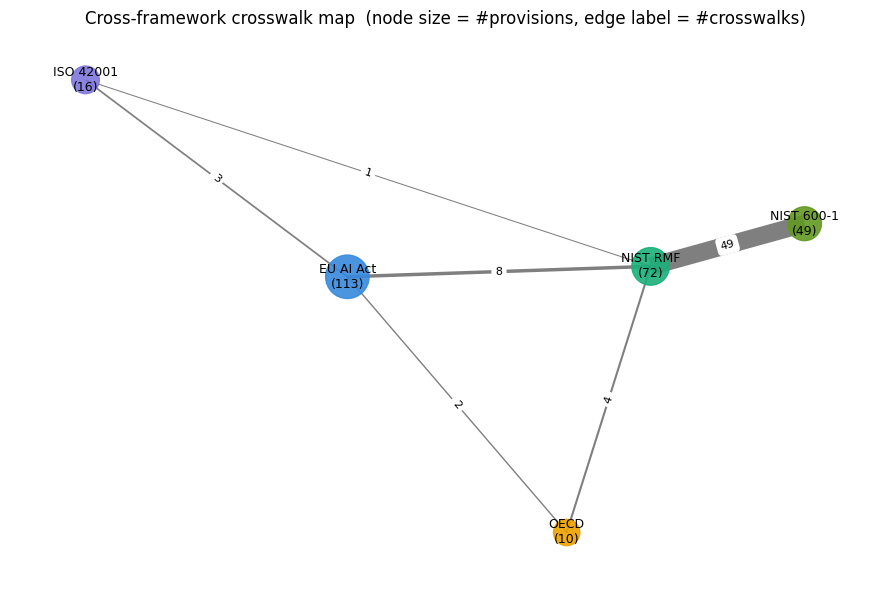

In [4]:
# The knowledge network at a glance: frameworks linked by the number of cited crosswalks.
_ = reg.framework_map()   # needs matplotlib

### Retrieval quality (does it find the right provision?)

A small labelled `issue → expected-provisions` set measures the data store — `hit` (any expected provision retrieved), `recall@k`, and `MRR`. This is how we tell whether a change to chunking or embeddings actually helps, rather than guessing. (Extend `regulus/eval.py` as coverage grows.)

In [5]:
# Retrieval quality on a small labelled eval set (hit-rate / recall@k / MRR).
demo.retrieval_report(reg, top_k=5)

,issue,hit,recall@k,mrr,top-1
0,Real-time facial recognition in public spaces ...,1.0,1.000,1.000,"EU AI Act, Article 5 — Prohibited AI practices"
1,Our credit model was deployed without testing ...,1.0,1.000,0.250,"NIST AI 600-1 (GenAI Profile), MS-2.11 — MEASU..."
2,No post-deployment monitoring of a high-risk A...,1.0,0.500,1.000,"EU AI Act, Article 72 — Post-market monitoring..."
3,Users are not told they are interacting with a...,1.0,1.000,1.000,"EU AI Act, Article 50 — Transparency obligatio..."
4,No human oversight of the model's automated de...,1.0,1.000,1.000,"EU AI Act, Article 14 — Human oversight"
5,The high-risk system was not validated for acc...,1.0,1.000,1.000,"EU AI Act, Article 15 — Accuracy, robustness a..."
6,No logging or records of the AI system's opera...,1.0,1.000,1.000,"EU AI Act, Article 12 — Record-keeping"
7,There is no risk management system for our hig...,1.0,1.000,1.000,"EU AI Act, Article 9 — Risk management system"
8,We provide no instructions for use or transpar...,1.0,1.000,1.000,"EU AI Act, Article 13 — Transparency and provi..."
9,No fundamental rights impact assessment was pe...,1.0,1.000,1.000,"EU AI Act, Article 27 — Fundamental rights imp..."


## 4. Test scenarios

Realistic, multi-issue observations. Pick one (or write your own) to run through the system.

In [6]:
# A categorized set of hypothetical scenarios (one per governance theme) lives in
# the module, so it's reusable and testable. Pick one to walk through.
from regulus import demo

for name in demo.SCENARIOS:
    print("\u2022", name)

scenario = demo.SCENARIOS['Security \u2014 adversarial & prompt injection']
print("\n" + scenario)

• Prohibited use — biometric surveillance
• Bias — credit underwriting
• Transparency — undisclosed chatbot
• Human oversight — automated decisions
• Safety & robustness — unvalidated high-risk system
• Security — adversarial & prompt injection
• Privacy — personal data governance
• Record-keeping — no logging
• Risk management — no process
• Post-market monitoring — none
• Documentation & rights impact
• GenAI — hallucination & provenance

Our public LLM assistant has no defences against prompt injection or data-poisoning, and we have done no adversarial or cybersecurity testing of the model or its data pipeline.


## 5. Assess a scenario

`reg.assess(scenario)` produces the full, **reproducible** assessment, now organized as tables:

1. **Risks, standards & controls** \u2014 each risk, the provisions (standards) that govern it, and a suggested control/mitigant (a curated, deterministic control library \u2014 *pre-built rules*, not LLM output).
2. **Priority (graph leverage)** \u2014 which provision to address *first*. This is the knowledge-network insight (see \u00a76).
3. **Cross-framework reach** \u2014 provisions the graph surfaces by following crosswalks, that similarity retrieval alone missed.
4. **Interpretation & recommended mitigants** \u2014 the LLM narrates *why* and adds scenario-specific mitigants, each grounded in a cited provision.

Pass `export=True` to save the report to `artifacts/assessments/` as Markdown + JSON + CSV (deterministic core \u2192 byte-identical across runs; only \u00a74's wording can vary).

In [7]:
# Full assessment (rendered) + saved to artifacts/assessments/
assessment = reg.assess(scenario, export=True)

## Regulus assessment
**System under review:** A generative-AI customer-service assistant for a retail bank. It answers customer questions about mortgages, savings, and credit cards by retrieving from internal product documentation, and is live to the public.
**Scenario:** Our public LLM assistant has no defences against prompt injection or data-poisoning, and we have done no adversarial or cybersecurity testing of the model or its data pipeline.

### 1. Risks, standards & controls
| risk | relevant provisions (standards) | suggested control / mitigant |
| --- | --- | --- |
| Secure and resilient | EU AI Act, Article 15 — Accuracy, robustness and cybersecurity \| EU AI Act, Article 55 — Obligations of providers of general-purpose AI models with systemic risk \| EU AI Act, Article 113 — Entry into force and application \| NIST AI 600-1 (GenAI Profile), MP-4.1 — MAP 4.1 — generative-AI suggested actions \| EU AI Act, Article 60 — Testing of high-risk AI systems in real world conditions outside AI regulatory sandboxes | Protect the system against adversarial attack and unexpected conditions, and recover gracefully. |
| Fair — with harmful bias managed | EU AI Act, Article 113 — Entry into force and application \| NIST AI 600-1 (GenAI Profile), MP-4.1 — MAP 4.1 — generative-AI suggested actions | Address equality/equity concerns and manage harmful bias across groups. |
| Privacy-enhanced | EU AI Act, Article 55 — Obligations of providers of general-purpose AI models with systemic risk \| NIST AI 600-1 (GenAI Profile), MP-4.1 — MAP 4.1 — generative-AI suggested actions | Safeguard privacy values such as confidentiality, anonymity and data minimisation. |
| Safe | EU AI Act, Article 15 — Accuracy, robustness and cybersecurity \| EU AI Act, Article 60 — Testing of high-risk AI systems in real world conditions outside AI regulatory sandboxes | Ensure the system does not lead to unacceptable harm under defined conditions of use. |
| Valid and reliable | EU AI Act, Article 15 — Accuracy, robustness and cybersecurity \| EU AI Act, Article 113 — Entry into force and application | Establish that the system performs accurately and reliably for its intended use before and after deployment. |
| Accountable and transparent | EU AI Act, Article 55 — Obligations of providers of general-purpose AI models with systemic risk | Make information and responsibility available across the lifecycle, with records that support audit. |
| Explainable and interpretable | EU AI Act, Article 60 — Testing of high-risk AI systems in real world conditions outside AI regulatory sandboxes | Ensure the mechanisms and meaning of outputs can be explained and interpreted for the audience. |

### 2. Priority — what to address first (graph leverage)
**Linchpin: EU AI Act, Article 15 — Accuracy, robustness and cybersecurity.** Highest leverage — relevant *and* the most connected provision in this scenario: it links 4 framework(s) (EU AI Act, NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0, OECD AI Principles) and shares risks with 4 other finding(s). Addressing it advances the most of the rest.

| rank | provision | relevance | frameworks linked | findings connected | leverage | priority score |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | EU AI Act, Article 15 — Accuracy, robustness and cybersecurity | 0.463 | 4 | 4 | 7 | 3.8127 |
| 2 | NIST AI 600-1 (GenAI Profile), MP-4.1 — MAP 4.1 — generative-AI suggested actions | 0.403 | 2 | 4 | 5 | 2.5215 |
| 3 | EU AI Act, Article 55 — Obligations of providers of general-purpose AI models with systemic risk | 0.421 | 1 | 4 | 4 | 2.1933 |
| 4 | EU AI Act, Article 113 — Entry into force and application | 0.403 | 1 | 4 | 4 | 2.0954 |
| 5 | EU AI Act, Article 60 — Testing of high-risk AI systems in real world conditions outside AI regulatory sandboxes | 0.396 | 1 | 4 | 4 | 2.0602 |

### 3. Cross-framework reach (via the knowledge graph)
Related provisions the graph surfaces by following cited crosswalks — the *same concern in other frameworks*, which similarity retrieval alone did not return:

| provision (via graph) | framework | hops | path |
| --- | --- | --- | --- |
| NIST AI RMF 1.0, MAP 4.1 — Map function | NIST AI RMF 1.0 | 1 | NIST AI 600-1 (GenAI Profile), MP-4.1 — MAP 4.1 — generative-AI suggested actions → NIST AI RMF 1.0, MAP 4.1 — Map function |
| NIST AI RMF 1.0, MEASURE 2.7 — Measure function | NIST AI RMF 1.0 | 1 | EU AI Act, Article 15 — Accuracy, robustness and cybersecurity → NIST AI RMF 1.0, MEASURE 2.7 — Measure function |
| OECD AI Principles, Principle 1.4 — Robustness, security and safety | OECD AI Principles | 1 | EU AI Act, Article 15 — Accuracy, robustness and cybersecurity → OECD AI Principles, Principle 1.4 — Robustness, security and safety |
| NIST AI 600-1 (GenAI Profile), MS-2.7 — MEASURE 2.7 — generative-AI suggested actions | NIST AI 600-1 (GenAI Profile) | 2 | EU AI Act, Article 15 — Accuracy, robustness and cybersecurity → NIST AI RMF 1.0, MEASURE 2.7 — Measure function → NIST AI 600-1 (GenAI Profile), MS-2.7 — MEASURE 2.7 — generative-AI suggested actions |

### 4. Interpretation & recommended mitigants
_Generated by gpt-5-4-20260305-gs at temperature 0 (labeled, best-effort reproducible) over the exact provisions above._

## 1. Why these provisions apply

- **EU AI Act Article 15** applies because the issue is specifically about missing defenses against prompt injection, data poisoning, and lack of cybersecurity/adversarial testing; Article 15 requires resilience against attempts by unauthorized third parties to alter use, outputs, or performance by exploiting vulnerabilities, and ties this to cybersecurity of high-risk AI systems (EU AI Act Article 15).
- **EU AI Act Article 55** may apply only if the bank is itself a **provider of a general-purpose AI model with systemic risk**; if that role/status is in scope, the provision is relevant to secure/resilient governance of such models, but the context provided does not establish that this customer-service assistant meets that threshold (EU AI Act Article 55).
- **EU AI Act Article 113** is relevant only indirectly from the text provided here, because it references documentation on how data was obtained/selected and measures to detect unsuitable data sources and identifiable biases; that is pertinent to the observed absence of controls over the data pipeline, though this context does not provide a full operative obligation beyond that excerpt (EU AI Act Article 113).
- **NIST AI 600-1 MP-4.1** applies because it flags generative-AI risk areas including offensive cyber capabilities and training-data issues, which is directly relevant to prompt-injection, poisoning, and broader secure/resilient risk identification for a public-facing GenAI assistant (NIST AI 600-1 MP-4.1).
- **EU AI Act Article 60** is potentially relevant if the bank is testing this live public system in real-world conditions; the provision governs testing of high-risk AI systems in real-world conditions outside sandboxes, but the context here does not establish whether current operation is formal “testing” under Article 60 (EU AI Act Article 60).

## 2. Root cause & related provisions

### Root governance gap
The core gap is **absence of a security-and-resilience control framework for the model and its data pipeline**, evidenced by no defenses against manipulation attempts and no adversarial/cybersecurity testing, which conflicts most directly with the requirement that systems be resilient to unauthorized attempts to alter use, outputs, or performance through vulnerabilities (EU AI Act Article 15).

A secondary gap is **insufficient governance over data-source suitability and data-selection controls**, given the stated lack of protections against data poisoning and the excerpted expectation to document how data was obtained/selected and detect unsuitable data sources (EU AI Act Article 113).

### Related guidance from cross-framework mappings
- **NIST AI RMF 1.0 MEASURE 2.7** is listed as **related guidance** to Article 15, with source note **“curated seed (thematic) — verify vs authoritative crosswalk”**; it reinforces the need to measure and assess security/robustness characteristics relevant to exploitation and manipulation risks, but should be treated as related guidance rather than an authoritative legal crosswalk from the context provided (related to EU AI Act Article 15; source: curated seed — verify).
- **OECD AI Principle 1.4** is also listed as **related guidance** to Article 15, again with source note **“curated seed (thematic) — verify”**; it reinforces the same robustness, security, and safety theme at principle level, but is not an authoritative one-to-one mapping in this context (related to EU AI Act Article 15; source: curated seed — verify).
- **NIST AI 600-1 MP-4.1 ↔ NIST AI RMF MAP 4.1** is a stronger linkage because the context says NIST AI 600-1 keys its suggested actions to AI RMF subcategories via an **authoritative structural mapping**; this supports using GenAI-specific risk identification for cyber/offensive-capability and data-related harms as part of governance for this assistant (NIST AI 600-1 MP-4.1; related to NIST AI RMF MAP 4.1, source: authoritative structural mapping).

## 3. Recommended mitigants

1. **Implement technical defenses against prompt injection and other manipulation attempts in the live system and retrieval flow** — prioritize controls intended to prevent unauthorized third parties from altering the system’s use, outputs, or performance by exploiting vulnerabilities, because that is the core resilience/cybersecurity expectation in the context provided (EU AI Act Article 15).

2. **Conduct targeted adversarial and cybersecurity testing before and during operation** — test the model, orchestration layer, retrieval components, and interfaces specifically for exploitation paths that could change outputs or performance, since Article 15 is expressly concerned with resilience against exploitation of vulnerabilities (EU AI Act Article 15).

3. **Assess and harden the data pipeline against poisoning and unsuitable sources** — document how data is obtained and selected, and introduce measures to detect unsuitable data sources, as this is the clearest data-governance basis in the provided context for addressing poisoning-related weaknesses (EU AI Act Article 113).

4. **Expand risk identification for this public GenAI assistant to explicitly include cyber-abuse and data-related failure modes** — use GenAI-specific risk mapping that covers offensive cyber capability concerns and training-data issues so these risks are formally identified and tracked in governance artifacts (NIST AI 600-1 MP-4.1).

5. **If the current public deployment is being used as real-world testing, bring that activity under a formal testing governance process** — determine whether operation qualifies as testing in real-world conditions and, if so, manage it under the applicable testing framework rather than informal live experimentation (EU AI Act Article 60).

6. **Clarify whether any GPAI systemic-risk obligations are in scope for the organization or upstream model provider** — if the bank is not the provider of a general-purpose AI model with systemic risk, Article 55 may not be the operative provision; if it is in scope, include that provision in the secure/resilient governance review (EU AI Act Article 55).

### Practical prioritization
For this fact pattern, the strongest primary basis in the supplied context is **EU AI Act Article 15**, supported by **Article 113** for data-source/data-selection governance and **NIST AI 600-1 MP-4.1** for GenAI-specific risk identification. The context is **not sufficient** to make stronger claims about Article 55 applicability or to prescribe detailed testing procedures beyond the high-level need to address resilience, cybersecurity, and data-source suitability (EU AI Act Article 15; EU AI Act Article 113; NIST AI 600-1 MP-4.1).

---
_Reproducibility: sections 1–3 are computed by code from a single retrieval pass (retriever: **embedding**, top_k=5) over a fixed data store — identical on every run for the same scenario. Only the wording of section 4 may vary._

[saved] artifacts/assessments/our-public-llm-assistant-has-no-defences-against-20260728-021548


In [8]:
# The same core as tidy DataFrames (nice for filtering / exporting elsewhere):
assessment.risk_table()

,risk,relevant provisions (standards),suggested control / mitigant
0,Secure and resilient,"EU AI Act, Article 15 — Accuracy, robustness a...",Protect the system against adversarial attack ...
1,Fair — with harmful bias managed,"EU AI Act, Article 113 — Entry into force and ...",Address equality/equity concerns and manage ha...
2,Privacy-enhanced,"EU AI Act, Article 55 — Obligations of provide...",Safeguard privacy values such as confidentiali...
3,Safe,"EU AI Act, Article 15 — Accuracy, robustness a...",Ensure the system does not lead to unacceptabl...
4,Valid and reliable,"EU AI Act, Article 15 — Accuracy, robustness a...",Establish that the system performs accurately ...
5,Accountable and transparent,"EU AI Act, Article 55 — Obligations of provide...",Make information and responsibility available ...
6,Explainable and interpretable,"EU AI Act, Article 60 — Testing of high-risk A...",Ensure the mechanisms and meaning of outputs c...


## 6. What the knowledge network adds (vs flat RAG)

Flat RAG returns the documents most *similar* to the scenario \u2014 and stops. Because similarity clusters within a framework, it tends to miss the same concern expressed elsewhere and has no notion of how its hits relate.

Regulus reads the **relationships** in the graph and turns them into insight:

- **Cross-framework reach** \u2014 follow cited crosswalks (even multi-hop) to surface related provisions in *other* frameworks that similarity never returned.
- **Leverage / linchpin** \u2014 rank provisions by relevance **\u00d7** how connected they are (frameworks linked, findings sharing risks, plus personalized-PageRank centrality). The top one is the provision to fix first: addressing it advances the most other findings.

The comparison below quantifies the difference on this scenario.

In [9]:
# Flat RAG vs Regulus GraphRAG \u2014 measured, not asserted:
_ = reg.compare_rag(scenario)

### Flat RAG vs Regulus GraphRAG — *Our public LLM assistant has no defences against prompt injection or data-poison*

| dimension | flat RAG (similarity only) | Regulus GraphRAG |
| --- | --- | --- |
| provisions surfaced | 5 | 9 |
| frameworks covered | 2 | 4 |
| cross-framework links used | 0 | 3 |
| risks identified | 0 | 7 |
| prioritized 'address-first' | — | EU AI Act, Article 15 — Accuracy, robustness and cybersecurity |

In [10]:
# The leverage ranking behind the linchpin (address-first) recommendation:
reg.priority(scenario)

,rank,provision,relevance,frameworks linked,findings connected,leverage,priority score
0,1,"EU AI Act, Article 15 — Accuracy, robustness a...",0.463,"EU AI Act, NIST AI 600-1 (GenAI Profile), NIST...",4,7,3.8127
1,2,"NIST AI 600-1 (GenAI Profile), MP-4.1 — MAP 4....",0.403,"NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0",4,5,2.5215
2,3,"EU AI Act, Article 55 — Obligations of provide...",0.421,EU AI Act,4,4,2.1933
3,4,"EU AI Act, Article 113 — Entry into force and ...",0.403,EU AI Act,4,4,2.0954
4,5,"EU AI Act, Article 60 — Testing of high-risk A...",0.396,EU AI Act,4,4,2.0602


## 7. Visualize the regulatory neighborhood

`reg.visualize(scenario)` draws the local map of the scenario in the knowledge network, then renders a **reading** of it beneath the figure:

- **Bold-outlined squares** = the *direct-hit* provisions (what the scenario most directly implicates).
- **Plain squares** = *cited crosswalk* provisions they link to, colored by framework — the same concern in other standards.
- **Grey circles** = the *risk categories* those provisions address.

The description is built for **consistency and reproducibility**: its facts (direct hits, cross-framework reach, risks, linchpin) are computed by code from the same graph and fill a fixed template, so they never contradict the diagram or the assessment. With an API key, the LLM narrates *those exact facts* at temperature 0 (labeled) and the deterministic facts are shown underneath; without one, the template itself is the description. Pass `with_llm=False` to force the template-only reading.

_Reading generated by gpt-5-4-20260305-gs at temperature 0 (labeled, grounded in the deterministic facts below)._

- **What the scenario implicates:** EU AI Act, Article 15 — Accuracy, robustness and cybersecurity, EU AI Act, Article 55 — Obligations of providers of general-purpose AI models with systemic risk, and EU AI Act, Article 113 — Entry into force and application, because the scenario describes no defences against prompt injection or data-poisoning and no adversarial or cybersecurity testing of the model or its data pipeline.
- **How the frameworks connect:** Following cited crosswalks, the graph also connects NIST AI RMF 1.0, MEASURE 2.7 — Measure function, OECD AI Principles, Principle 1.4 — Robustness, security and safety, and NIST AI 600-1 (GenAI Profile), MS-2.7 — MEASURE 2.7 — generative-AI suggested actions — the same concern expressed across 4 framework(s) (EU AI Act, NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0, OECD AI Principles). Similarity retrieval alone returned only the direct hits.
- **Risks in play:** Secure and resilient, Valid and reliable, Accountable and transparent, Fair — with harmful bias managed, Privacy-enhanced, Safe (grey circles). *Secure and resilient* links the most findings.
- **Where to start:** EU AI Act, Article 15 — Accuracy, robustness and cybersecurity. The most connected provision — links 4 framework(s) and shares risks with 2 other finding(s); fixing it advances the most of the rest.

**Facts (deterministic, reproducible):**

**Reading the neighborhood**

- **Direct hits (3):** EU AI Act, Article 15 — Accuracy, robustness and cybersecurity, EU AI Act, Article 55 — Obligations of providers of general-purpose AI models with systemic risk, EU AI Act, Article 113 — Entry into force and application. The provisions this scenario most directly implicates (bold-outlined squares).
- **Cross-framework reach (3):** following cited crosswalks, the graph also connects NIST AI RMF 1.0, MEASURE 2.7 — Measure function, OECD AI Principles, Principle 1.4 — Robustness, security and safety, NIST AI 600-1 (GenAI Profile), MS-2.7 — MEASURE 2.7 — generative-AI suggested actions — the same concern expressed across 4 framework(s) (EU AI Act, NIST AI 600-1 (GenAI Profile), NIST AI RMF 1.0, OECD AI Principles). Similarity retrieval alone returned only the direct hits.
- **Risks in play (6):** Secure and resilient, Valid and reliable, Accountable and transparent, Fair — with harmful bias managed, Privacy-enhanced, Safe (grey circles). *Secure and resilient* links the most findings.
- **Address first — linchpin:** EU AI Act, Article 15 — Accuracy, robustness and cybersecurity. The most connected provision — links 4 framework(s) and shares risks with 2 other finding(s); fixing it advances the most of the rest.

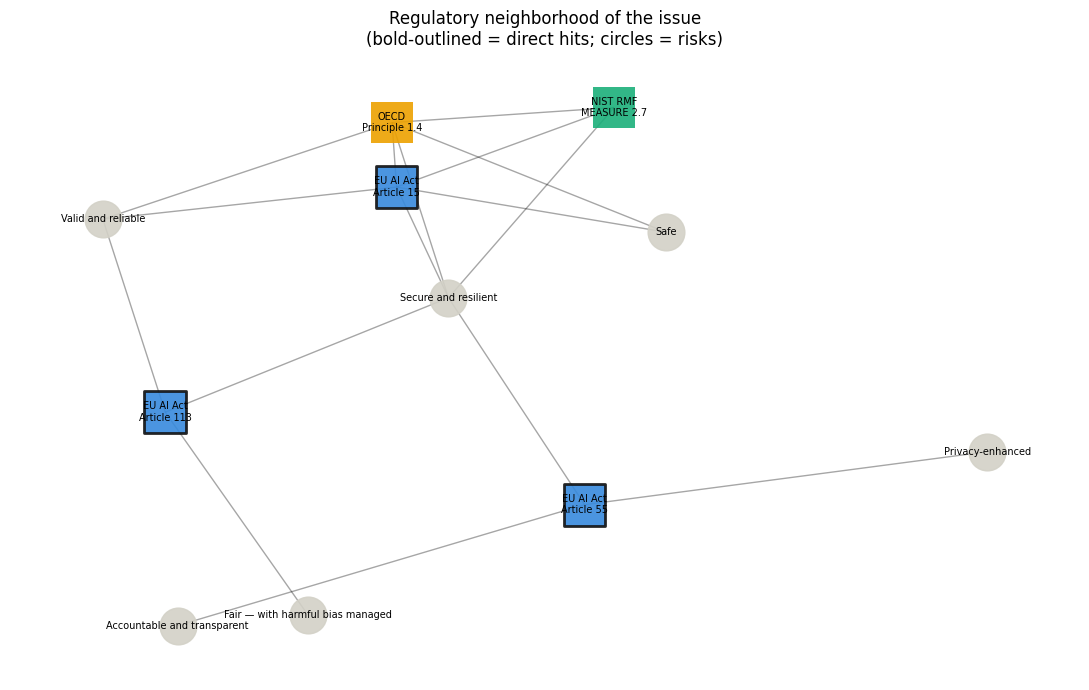

In [11]:
_ = reg.visualize(scenario, top_k=3)   # figure + reproducible description (needs matplotlib)

## 8. Coverage across scenarios

Run the whole categorized scenario set at once to see how well the corpus covers different governance themes \u2014 which frameworks and risk categories each scenario exercises. A quick way to spot gaps (a theme where too few frameworks or risks light up may need more crosswalks or provisions).

In [12]:
demo.coverage_report(reg)

,scenario,top provision,frameworks hit,risks identified,risk categories
0,Prohibited use — biometric surveillance,"EU AI Act, Article 5 — Prohibited AI practices",1,6,"Accountable and transparent, Fair — with harmf..."
1,Bias — credit underwriting,"EU AI Act, Article 113 — Entry into force and ...",2,7,"Accountable and transparent, Explainable and i..."
2,Transparency — undisclosed chatbot,"EU AI Act, Article 14 — Human oversight",2,5,"Accountable and transparent, Fair — with harmf..."
3,Human oversight — automated decisions,"EU AI Act, Article 6 — Classification rules fo...",1,6,"Accountable and transparent, Fair — with harmf..."
4,Safety & robustness — unvalidated high-risk sy...,"EU AI Act, Article 9 — Risk management system",2,5,"Fair — with harmful bias managed, Privacy-enha..."
5,Security — adversarial & prompt injection,"EU AI Act, Article 15 — Accuracy, robustness a...",2,7,"Accountable and transparent, Explainable and i..."
6,Privacy — personal data governance,"EU AI Act, Article 10 — Data and data governance",2,7,"Accountable and transparent, Explainable and i..."
7,Record-keeping — no logging,"EU AI Act, Article 12 — Record-keeping",1,5,"Accountable and transparent, Privacy-enhanced,..."
8,Risk management — no process,"EU AI Act, Article 9 — Risk management system",1,5,"Accountable and transparent, Privacy-enhanced,..."
9,Post-market monitoring — none,"EU AI Act, Article 72 — Post-market monitoring...",1,5,"Accountable and transparent, Fair — with harmf..."


## What's next

- **Sharper retrieval** — set `RETRIEVER = 'embedding'` above for embedding-quality context.
- **Evidence paths** — return the full trail (issue → provision → crosswalk → provision) via GKN's path explainer.
- **Measure the claim** — benchmark the graph-grounded answer against a flat-RAG baseline.
- **Interface** — a "submit an issue" web UI.

**Extend Regulus:** add crosswalk rows or frameworks under `data/`, or swap the seed crosswalks for authoritative mappings.